<a href="https://colab.research.google.com/github/MariamKSharkawy/ML-projects/blob/ML_DL_projects/retino_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# this is a submission to the competition to predict the severity of diabetes based on retinopathy

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

read the directory that has all the necessary files and folders

In [ ]:
import os
data_path = '/kaggle/input/diabetic-retinopathy-classification-f1-score-4/kaggle_retina'
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

print(csv_files)

['submission.csv', 'train.csv']


# reading and exploring the train and test files

In [ ]:
#read how many data in the train file
train_path='/kaggle/input/diabetic-retinopathy-classification-f1-score-4/kaggle_retina/train'
img_count=sum(1 for file in os.listdir(train_path) if file.lower().endswith('.png'))
print(img_count)

2197


In [ ]:
#read how many data in the test file
test_path='/kaggle/input/diabetic-retinopathy-classification-f1-score-4/kaggle_retina/test'
img_count=sum(1 for file in os.listdir(test_path) if file.lower().endswith('.png'))
print(img_count)

1465


In [ ]:
#read the train and submission.csv files
df=pd.read_csv('/kaggle/input/diabetic-retinopathy-classification-f1-score-4/kaggle_retina/train.csv')
df.head()

,id_code,diagnosis
0,c1e6fa1ad314,1
1,ed246ae1ed08,4
2,4d3de40ced3a,0
3,ae8472f8d310,1
4,3c28fd846b43,0


In [ ]:
submission=pd.read_csv('/kaggle/input/diabetic-retinopathy-classification-f1-score-4/kaggle_retina/submission.csv')
submission.head()

,id_code,diagnosis
0,de4cdabbce6d,4
1,ba08cee68c71,4
2,537e50fdf22e,4
3,ab1c20a94f3f,4
4,3aa2b1ce6700,4


In [ ]:
#create another column in the train.csv file that contains the relative image path
df['img_path']=df['id_code'].apply(lambda x: os.path.join(train_path,x+'.png'))

In [ ]:
#double check the file heads
df.head()

,id_code,diagnosis,img_path
0,c1e6fa1ad314,1,/kaggle/input/diabetic-retinopathy-classificat...
1,ed246ae1ed08,4,/kaggle/input/diabetic-retinopathy-classificat...
2,4d3de40ced3a,0,/kaggle/input/diabetic-retinopathy-classificat...
3,ae8472f8d310,1,/kaggle/input/diabetic-retinopathy-classificat...
4,3c28fd846b43,0,/kaggle/input/diabetic-retinopathy-classificat...


# display a sample of the data

2025-05-21 22:57:23.226518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747868243.454011      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747868243.516490      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1747868258.003797      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747868258.004572      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

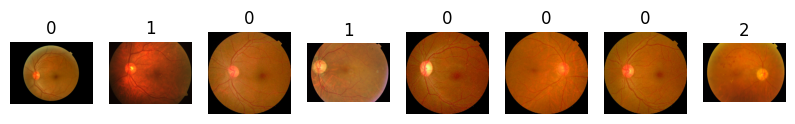

In [ ]:
import tensorflow as tf
samples=df.sample(8)
plt.figure(figsize=(10,8))
for i, (path,label) in enumerate(zip(samples['img_path'],samples['diagnosis'])):
    img=tf.io.read_file(path)
    img=tf.image.decode_png(img, channels=3)
    plt.subplot(1,8,i+1)
    plt.title(label)
    plt.axis('off')
    plt.imshow(img.numpy())

# split the data into train and validation #

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val=train_test_split(df['img_path'],df['diagnosis'],test_size=0.2,random_state=42)

# load and preprocess each image

In [ ]:
#create a function to adjust the images for the tensorflow manipulation and make sure they are all the same size
def process_img(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_png(img, channels=3)
    img=tf.image.resize(img,[224,224])   #resize
    img=img/255.0   #normalize
    return img, label

# create tensor flow datasets

In [ ]:
train_ds=tf.data.Dataset.from_tensor_slices((x_train.values,y_train.values))
train_ds=train_ds.map(process_img).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds=tf.data.Dataset.from_tensor_slices((x_val.values,y_val.values))
val_ds=val_ds.map(process_img).batch(32).prefetch(tf.data.AUTOTUNE)

# create the model

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D,MaxPooling2D,Flatten

model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,(3,3),activation='relu'),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(5,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )
history=model.fit(train_ds,validation_data=val_ds,epochs=5)

Epoch 1/5


I0000 00:00:1747868262.981290      62 service.cc:148] XLA service 0x7d1788005190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747868262.982519      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747868262.982539      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747868263.360174      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/55 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.1406 - loss: 2.4312  

I0000 00:00:1747868273.030914      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 373ms/step - accuracy: 0.5170 - loss: 1.4665 - val_accuracy: 0.7114 - val_loss: 0.8249
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.6870 - loss: 0.7994 - val_accuracy: 0.7159 - val_loss: 0.7783
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7048 - loss: 0.7717 - val_accuracy: 0.7114 - val_loss: 0.7515
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7236 - loss: 0.7370 - val_accuracy: 0.7159 - val_loss: 0.7700
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.7223 - loss: 0.7226 - val_accuracy: 0.7273 - val_loss: 0.7718


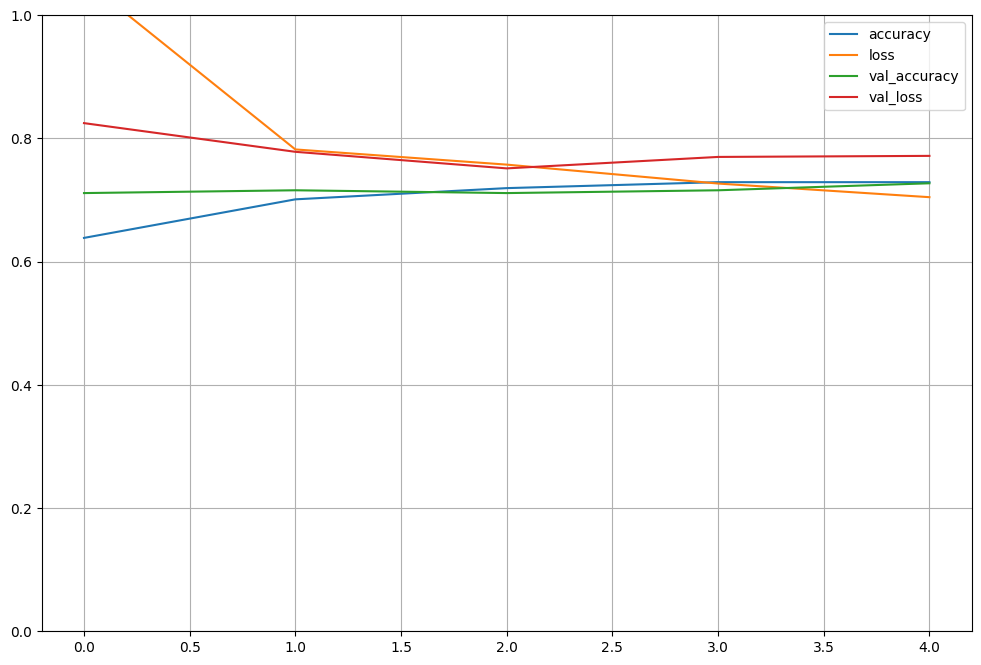

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7217 - loss: 0.8234
Loss     :  0.7717580795288086
accuracy :  0.7272727489471436


In [ ]:
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

# Evaluate the model
model_evaluate = model.evaluate(val_ds)
print("Loss     : ",model_evaluate[0])
print("accuracy : ",model_evaluate[1])

# work on submitting the predictions in the submissions file

In [ ]:
#in the submission.csv file, create a coulmn that has the full path each image
submission['img_path'] = submission['id_code'].apply(lambda x: os.path.join(test_path, x + '.png'))

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(submission['img_path'].values)  #create a tf dataset
test_ds = test_ds.map(lambda path: process_img(path, 0)[0])  # Drop label, keep image
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE) #to make the model faster by batching and prefectching

In [ ]:
#now use the model trained to predict the data in test_ds
predictions = model.predict(test_ds)
predicted_classes = np.argmax(predictions, axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step


In [ ]:
#replace the values in the diagnosis column with the predicted values
submission['diagnosis'] = predicted_classes

In [ ]:
#overwrite the file submission with the new findings
submission[['id_code', 'diagnosis']].to_csv('submission.csv', index=False)

In [ ]:
#see the different classes predicted
submission.head()
submission['diagnosis'].value_counts()

diagnosis
0    810
2    607
4     29
3     12
1      7
Name: count, dtype: int64